# Euclidean vs. Network Distance — A Small Study

**Research statement.** This notebook defines a simple street-like network and compares straight-line (Euclidean) distance with network (street-path) distance for pairs of locations. It asks: *How do physical barriers and street connectivity change the distance you actually experience versus how far things are “as the crow flies”?*

In [1]:
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import LineString, MultiLineString, Point, Polygon
import pandas as pd
import requests
import networkx as nx
import osmnx as ox
import folium
from folium import plugins
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings("ignore")

In [2]:
# Set up plotting parameters
def set_axis_off():
    """Set matplotlib to turn off axes and ticks by default."""

In [3]:
import math, random
import numpy as np, pandas as pd, networkx as nx
import matplotlib.pyplot as plt

rows, cols = 18, 30
dx, dy = 1.0, 1.0
barrier_col = 14
bridge_rows = [4, 9, 14]

G = nx.Graph()
pos = {}

for r in range(rows):
    for c in range(cols):
        node = (r, c)
        x = c * dx
        y = r * dy
        pos[node] = (x, y)
        G.add_node(node, x=x, y=y)

for r in range(rows):
    for c in range(cols):
        if c + 1 < cols:
            if c == barrier_col:
                if r in bridge_rows:
                    length = math.hypot(dx, 0)
                    G.add_edge((r, c), (r, c + 1), length=length)
            else:
                length = math.hypot(dx, 0)
                G.add_edge((r, c), (r, c + 1), length=length)
        if r + 1 < rows:
            length = math.hypot(0, dy)
            G.add_edge((r, c), (r + 1, c), length=length)


def euclid(a, b):
    (xa, ya) = pos[a]
    (xb, yb) = pos[b]
    return math.hypot(xb - xa, yb - ya)


orig = (8, 5)
dest = (10, 24)

path = nx.shortest_path(G, source=orig, target=dest, weight="length")
net_dist = nx.shortest_path_length(G, source=orig, target=dest, weight="length")
euc_dist = euclid(orig, dest)
detour_index = net_dist / euc_dist if euc_dist > 0 else np.nan
net_dist, euc_dist, detour_index

(21.0, 19.1049731745428, 1.0991902374394489)

## Map: Base Network

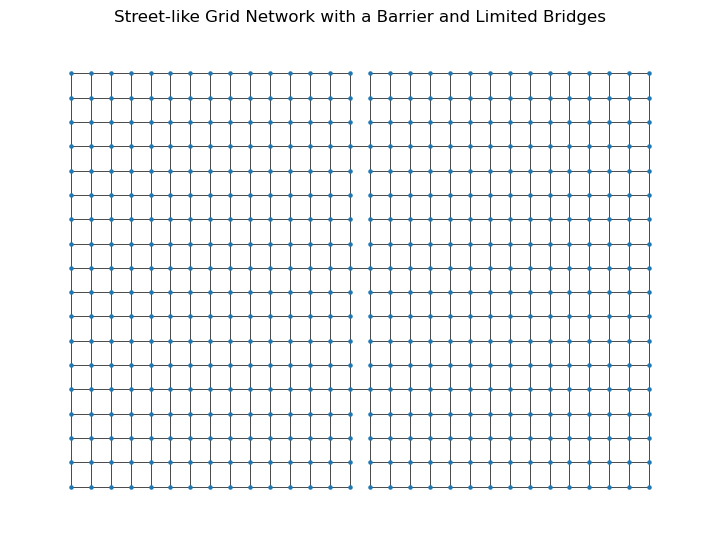

In [4]:
plt.figure(figsize=(7, 5))
nx.draw(G, pos, node_size=5, width=0.5)
plt.title("Street-like Grid Network with a Barrier and Limited Bridges")
plt.tight_layout()
plt.show()

## Map: Euclidean vs Network Path for a Sample O–D Pair

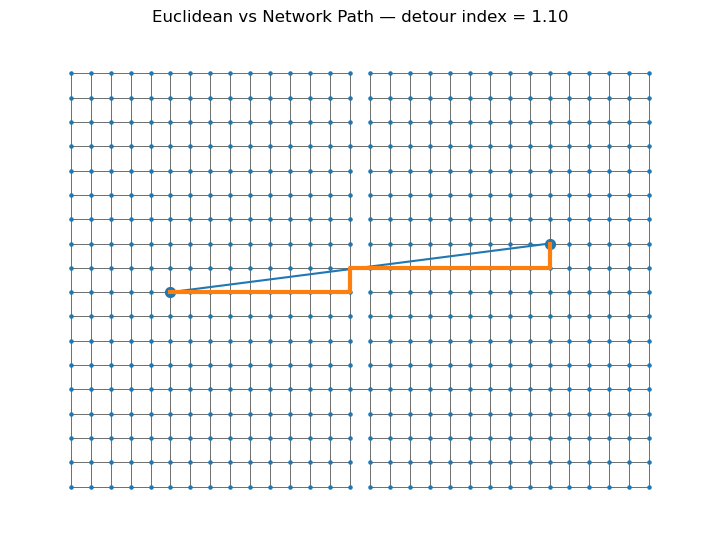

In [5]:
plt.figure(figsize=(7, 5))
nx.draw(G, pos, node_size=5, width=0.4)
x0, y0 = pos[orig]
x1, y1 = pos[dest]
plt.plot([x0, x1], [y0, y1])
path_xy = np.array([pos[n] for n in path])
plt.plot(path_xy[:, 0], path_xy[:, 1], linewidth=3)
plt.scatter([x0, x1], [y0, y1], s=50)
plt.title(f"Euclidean vs Network Path — detour index = {detour_index:.2f}")
plt.tight_layout()
plt.show()

## Random Pairs: Euclidean vs Network

In [6]:
random.seed(7)
pairs = []
for _ in range(400):
    a = (random.randrange(rows), random.randrange(cols))
    b = (random.randrange(rows), random.randrange(cols))
    if a != b and nx.has_path(G, a, b):
        e = euclid(a, b)
        n = nx.shortest_path_length(G, a, b, weight="length")
        d = n / e if e > 0 else np.nan
        pairs.append((a, b, e, n, d))

df = pd.DataFrame(
    pairs, columns=["origin", "dest", "euclid", "network", "detour_index"]
)
df.head()

,origin,dest,euclid,network,detour_index
0,"(10, 4)","(12, 20)",16.124515,20.0,1.240347
1,"(1, 2)","(17, 3)",16.031220,17.0,1.060431
2,"(11, 18)","(1, 29)",14.866069,21.0,1.412613
3,"(16, 6)","(1, 2)",15.524175,19.0,1.223898
4,"(13, 13)","(2, 7)",12.529964,17.0,1.356748


### Chart: Scatter — Euclidean vs Network Distance

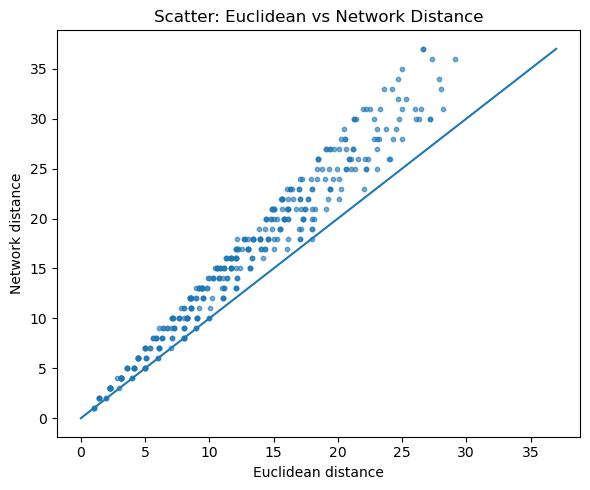

In [7]:
plt.figure(figsize=(6, 5))
plt.scatter(df["euclid"], df["network"], s=10, alpha=0.6)
max_val = max(df["euclid"].max(), df["network"].max())
plt.plot([0, max_val], [0, max_val])
plt.xlabel("Euclidean distance")
plt.ylabel("Network distance")
plt.title("Scatter: Euclidean vs Network Distance")
plt.tight_layout()
plt.show()

### Chart: Histogram — Detour Index

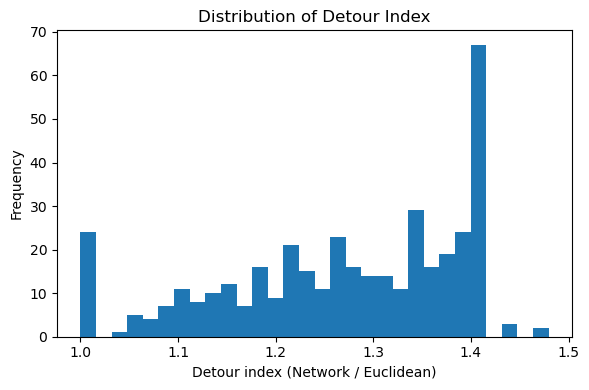

In [8]:
plt.figure(figsize=(6, 4))
plt.hist(df["detour_index"].dropna(), bins=30)
plt.xlabel("Detour index (Network / Euclidean)")
plt.ylabel("Frequency")
plt.title("Distribution of Detour Index")
plt.tight_layout()
plt.show()

## Reflection: Experiential Differences

*Euclidean* distance describes the straight-line separation between points—useful for intuition and rough comparability. But *network* distance captures the **path you can actually take**, which depends on **connectivity**, **barriers**, **legal access**, and **micro-geometry** (turns, crossings). In the map above, the north–south barrier forces travelers onto a handful of bridges. This produces **detours** that grow disproportionately for O–D pairs near—but split by—the barrier. As a result, places that are 'close' in Euclidean terms can feel **far** in lived experience. Conversely, within well-connected sub-grids, network and Euclidean distances converge, and movement feels more **direct** and **predictable**.

The **detour index** (network / Euclidean) summarizes this gap. Values near 1 indicate directness; higher values imply **circuitous** travel, often correlating with perceived friction—waiting at crossings, backtracking, or funneled flows. These experiential factors are central to urban wayfinding, accessibility planning, last‑mile logistics, and pedestrian comfort.